# R515B Soğutucu Sıvısı: STGP-EF Yöntemi ile Termodinamik Özellik Tahmini ve Model Yorumlanabilirliği Analizi

## Özet

Bu çalışmada, R515B termodinamik soğutucu sıvısının fiziksel özelliklerini tahmin etmek için Sembolik Transformer ve Evrimsel Orman (STGP-EF) yöntemi uygulanmıştır. Yöntem, makine öğrenmesi modellerini yorumlanabilir hale getirerek, otomatik olarak üretilen matematiksel formüller aracılığıyla termodinamik ilişkileri açığa çıkarmaktadır. Çalışmada, temel model (baseline) ile kıyasla STGP-EF yöntemi ile oluşturulan özelliklerin model performansına katkısı, özellik önemliği analizi ve termodinamik yasalara uygunluk incelenmektedir.

## 1. Giriş

### 1.1 Motivasyon

Makine öğrenmesi modelleri, özellikle ensemble ve gradient boosting yöntemleri, tahmin doğruluğunda önemli başarılar sağlamıştır. Ancak, bu modellerin "kara kutu" doğası, karar mekanizmalarının anlaşılmasını güçleştirmektedir. Termodinamik alanında çalışan mühendisler için, modelin tahminleri nasıl yaptığının ve bu tahminlerin fiziksel yasalara uygunluğunun bilinmesi kritik önem taşımaktadır.

### 1.2 STGP-EF Yöntemi

Sembolik Transformer (STGP), genetik programlama aracılığıyla otomatik olarak matematiksel formüller üretmektedir. Evrimsel Orman (EF) ise, evrimi kullanarak optimal ağaç yapılarını bularak ensemble tahminler sağlamaktadır. Bu iki yöntemin birleştirilmesi, hem açık formüllere hem de güçlü tahmin yeteneğine sahip bir model oluşturmaktadır.

### 1.3 Veri Seti

Çalışmada kullanılan R515B veri seti, doymuş kaynama ve kızgın buhar bölgelerinde ölçülen termodinamik özelliklerini içermektedir:

- **Doymuş Kaynama Bölgesi (Saturated)**: Sıvı-buhar karışımının dengedeki koşulları
- **Kızgın Buhar Bölgesi (Superheated)**: Sıcaklık doyma noktasını aşan koşullar

Tahmin edilen özellikler: P, v (sıvı), v (buhar), h (sıvı), h (buhar), s (sıvı), s (buhar)

## 2. Metodoloji

In [1]:
import sys
import os
from pathlib import Path

project_root = Path.cwd()
functions_path = project_root / 'Functions'
sys.path.insert(0, str(functions_path))
sys.path.insert(0, str(project_root))

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

from Functions.Feature_Construction_Method import (
    load_r515b_datasets, prepare_data, apply_stgp_ef, get_regressors,
    evaluate_regressors, evaluate_baseline_model, select_best_models,
    calculate_feature_importance, verify_thermodynamic_compliance
)

warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

2026-05-18 14:24:57,680 - INFO - Loading faiss with AVX2 support.
2026-05-18 14:24:57,697 - INFO - Successfully loaded faiss with AVX2 support.
c:\Users\SGUZEY\Documents\Yüksek Lisans Dersleri\Veri Mühendisliği\Data_Engineering_Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.1 Veri Seti Yükleme ve Ön İşleme

In [3]:
datasets = load_r515b_datasets()

df_saturated = datasets['saturated']
df_superheated = datasets['superheated']

# Veri seti özeti
data_summary = pd.DataFrame({
    'Dataset': ['Saturated', 'Superheated'],
    'Samples': [len(df_saturated), len(df_superheated)],
    'Features': [df_saturated.shape[1], df_superheated.shape[1]],
    'Missing Values': [df_saturated.isnull().sum().sum(), df_superheated.isnull().sum().sum()]
})

print("Data Set Summary")
print("=" * 60)
print(data_summary.to_string(index=False))
print("\n")

# Saturated Dataset Statistics
print("Saturated Region - Descriptive Statistics")
print("=" * 60)
print(df_saturated.describe().to_string())

2026-05-18 14:24:59,052 - INFO - Doymuş Veri Seti Yüklendi: (136, 8)
2026-05-18 14:24:59,053 - INFO - Kızgın Buhar Veri Seti Yüklendi: (578, 5)


Data Set Summary
    Dataset  Samples  Features  Missing Values
  Saturated      136         8               0
Superheated      578         5               0


Saturated Region - Descriptive Statistics
        T(girdi)    P(çıktı)  v sıvı (çıktı)  v buhar (çıktı)  h sıvı (çıktı)  h buhar (çıktı)  s sıvı (çıktı)  s buhar (çıktı)
count 136.000000  136.000000      136.000000       136.000000      136.000000       136.000000      136.000000       136.000000
mean   37.500000 1042.864324        0.000926         0.054111       94.706654       238.523456        0.361161         0.847033
std    39.403892  935.850024        0.000158         0.064105       57.724829        20.551542        0.182512         0.006818
min   -30.000000   61.221000        0.000745         0.003320        2.728200       198.200000        0.044640         0.814680
25%     3.750000  248.537500        0.000802         0.010188       45.102750       221.165000        0.207153         0.843540
50%    37.500000  716.865000  

In [4]:
print("Superheated Region - Descriptive Statistics")
print("=" * 60)
print(df_superheated.describe().to_string())

Superheated Region - Descriptive Statistics
       T (girdi)   P (girdi)  v (çıktı)  h (çıktı)  s (çıktı)
count 578.000000  578.000000 578.000000 578.000000 578.000000
mean   73.027682  987.283737   0.064798 275.340035   0.957587
std    28.295040  773.162310   0.098803  22.994860   0.080835
min   -30.000000   50.000000   0.003632 198.550000   0.827400
25%    55.000000  350.000000   0.013404 261.940000   0.893705
50%    80.000000  800.000000   0.026924 276.900000   0.941040
75%    95.000000 1500.000000   0.064513 292.270000   1.004250
max   105.000000 3300.000000   0.532510 318.950000   1.254100


### 2.2 STGP-EF Özellik Yapılandırması

In [5]:
saturated_inputs = ['T(girdi)']
saturated_outputs = ['P(çıktı)', 'v sıvı (çıktı)', 'v buhar (çıktı)',
                      'h sıvı (çıktı)', 'h buhar (çıktı)',
                      's sıvı (çıktı)', 's buhar (çıktı)']

saturated_results = {}
baseline_results_dict = {}

print("STGP-EF Feature Construction - Saturated Region")
print("=" * 60)

for output in saturated_outputs:
    try:
        # Data preparation
        X_train, X_test, y_train, y_test, scaler_x, scaler_y = prepare_data(
            df_saturated, saturated_inputs, output, test_size=0.3
        )
        
        # Baseline model evaluation (original features)
        baseline_metrics = evaluate_baseline_model(X_train, y_train, X_test, y_test)
        baseline_results_dict[output] = baseline_metrics
        
        # STGP-EF application
        X_train_hybrid, X_test_hybrid = apply_stgp_ef(X_train, y_train, X_test)
        
        saturated_results[output] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X_train_hybrid': X_train_hybrid,
            'X_test_hybrid': X_test_hybrid,
            'scaler_x': scaler_x,
            'scaler_y': scaler_y
        }
        
        print(f"{output}: Original features={X_train.shape[1]}, STGP-EF features={X_train_hybrid.shape[1]}")
        
    except Exception as e:
        print(f"Error processing {output}: {str(e)[:80]}")

STGP-EF Feature Construction - Saturated Region


2026-05-18 14:25:00,825 - INFO - Hibrit Özellik İnşası (STGP-EF) Başlatılıyor...
2026-05-18 14:25:08,639 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:25:08,639 - INFO - SYMBOLIC REGRESSION (STGP) - Generated Features (10 of 10)
2026-05-18 14:25:08,640 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:25:08,641 - INFO -   STGP_00: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,642 - INFO -   STGP_01: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,643 - INFO -   STGP_02: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,643 - INFO -   STGP_03: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,644 - INFO -   STGP_04: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,644 - INFO -   STGP_05: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,645 - INFO -   STGP_06: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,646 - INFO -   STGP_07: (x0 + ((x0 * 0.352) * x0))
2026-05-18 14:25:08,647 - INFO -  

P(çıktı): Original features=1, STGP-EF features=21


2026-05-18 14:27:15,714 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:27:15,714 - INFO - SYMBOLIC REGRESSION (STGP) - Generated Features (10 of 10)
2026-05-18 14:27:15,714 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:27:15,714 - INFO -   STGP_00: ((((x0 - -0.981) + (x0 * x0)) + 0.984) * (-0.915 - x0))
2026-05-18 14:27:15,714 - INFO -   STGP_01: ((-0.915 - x0) * (((x0 - -0.981) + (x0 * x0)) + 0.984))
2026-05-18 14:27:15,714 - INFO -   STGP_02: ((((x0 - -0.981) + (x0 * x0)) + 0.984) * (-0.915 - x0))
2026-05-18 14:27:15,714 - INFO -   STGP_03: ((((x0 - -0.981) + (x0 * x0)) + 0.984) * (-0.915 - x0))
2026-05-18 14:27:15,714 - INFO -   STGP_04: ((((x0 - -0.981) + (x0 * x0)) + 0.984) * (-0.915 - x0))
2026-05-18 14:27:15,714 - INFO -   STGP_05: ((((x0 - -0.981) + (x0 * x0)) + 0.984) * (-0.915 - x0))
2026-05-18 14:27:15,714 - INFO -   STGP_06: ((((x0 - -0.981) + (x0 * x0)) + 0.984) 

v sıvı (çıktı): Original features=1, STGP-EF features=21


...

h buhar (çıktı): Original features=1, STGP-EF features=21


2026-05-18 14:35:32,926 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:35:32,926 - INFO - SYMBOLIC REGRESSION (STGP) - Generated Features (10 of 10)
2026-05-18 14:35:32,926 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:35:32,926 - INFO -   STGP_00: (x0 * -0.204)
2026-05-18 14:35:32,926 - INFO -   STGP_01: ((((-0.012 + 0.171) + (0.972 + -0.844)) - ((x0 / x0) + (-0.473 * x0))) + (((x0 - x0) / (x0 / x0)) / ((x0 / x0) * (-0.282 - -0.701))))
2026-05-18 14:35:32,926 - INFO -   STGP_02: x0
2026-05-18 14:35:32,926 - INFO -   STGP_03: x0
2026-05-18 14:35:32,932 - INFO -   STGP_04: x0
2026-05-18 14:35:32,932 - INFO -   STGP_05: x0
2026-05-18 14:35:32,932 - INFO -   STGP_06: x0
2026-05-18 14:35:32,932 - INFO -   STGP_07: x0
2026-05-18 14:35:32,932 - INFO -   STGP_08: x0
2026-05-18 14:35:32,932 - INFO -   STGP_09: x0
2026-05-18 14:37:32,220 - INFO - 
─────────────────────────────────────

s sıvı (çıktı): Original features=1, STGP-EF features=21


2026-05-18 14:37:40,328 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:37:40,329 - INFO - SYMBOLIC REGRESSION (STGP) - Generated Features (10 of 10)
2026-05-18 14:37:40,330 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:37:40,330 - INFO -   STGP_00: (((((x0 * x0) + (0.888 + x0)) + (0.888 + x0)) + (0.888 + (((x0 * x0) + (0.888 + (0.888 + x0))) + 0.888))) * ((((x0 * -0.133) / (-0.233 / x0)) - (0.209 - -0.839)) * (0.888 + x0)))
2026-05-18 14:37:40,330 - INFO -   STGP_01: ((((((x0 * -0.133) / (-0.233 / x0)) - (0.209 - -0.839)) + (0.888 + (0.888 + x0))) + 0.888) * ((((x0 * -0.133) / (-0.233 / x0)) - (0.209 - -0.839)) * (0.888 + x0)))
2026-05-18 14:37:40,330 - INFO -   STGP_02: ((((x0 * x0) + (0.888 + x0)) + (0.888 + 0.888)) * ((((x0 * -0.133) / (-0.233 / x0)) - (0.209 - -0.839)) * (0.888 + x0)))
2026-05-18 14:37:40,330 - INFO -   STGP_03: ((((x0 * x0) + (0.888 + (0.888 + x0))) + 0.

s buhar (çıktı): Original features=1, STGP-EF features=21


### 2.3 Model Değerlendirmesi: Baseline vs STGP-EF

In [6]:
all_evaluation_results = {}
comparison_results = {}

print("Model Training and Evaluation")
print("=" * 80)

for output in saturated_outputs:
    if output not in saturated_results:
        continue
    
    print(f"\nOutput Variable: {output}")
    print("-" * 80)
    
    try:
        data = saturated_results[output]
        
        # Evaluate models with STGP-EF features
        results_stgpef = evaluate_regressors(
            data['X_train_hybrid'],
            data['y_train'],
            data['X_test_hybrid'],
            data['y_test']
        )
        
        results_df = pd.DataFrame(results_stgpef).T
        all_evaluation_results[output] = results_df
        
        # Prepare comparison table
        baseline_row = baseline_results_dict[output]
        
        # Select top-3 models from STGP-EF
        top3_models = results_df.nlargest(3, 'Test_R2').index.tolist()
        
        comparison_table = []
        comparison_table.append({
            'Model': 'Baseline (XGBoost)',
            'Test_R2': baseline_row['Test_R2'],
            'Test_RMSE': baseline_row['Test_RMSE'],
            'Test_MAE': baseline_row['Test_MAE'],
            'Test_MAPE': baseline_row['Test_MAPE']
        })
        
        for model_name in top3_models:
            comparison_table.append({
                'Model': f'STGP-EF + {model_name}',
                'Test_R2': results_df.loc[model_name, 'Test_R2'],
                'Test_RMSE': results_df.loc[model_name, 'Test_RMSE'],
                'Test_MAE': results_df.loc[model_name, 'Test_MAE'],
                'Test_MAPE': results_df.loc[model_name, 'Test_MAPE']
            })
        
        comparison_results[output] = pd.DataFrame(comparison_table)
        
        print("\nPerformance Comparison - Baseline vs Top-3 STGP-EF Models")
        print(comparison_results[output].to_string(index=False))
        
        # Calculate improvements
        best_stgpef_r2 = results_df['Test_R2'].max()
        baseline_r2 = baseline_row['Test_R2']
        r2_improvement = ((best_stgpef_r2 - baseline_r2) / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
        
        best_stgpef_mae = results_df['Test_MAE'].min()
        baseline_mae = baseline_row['Test_MAE']
        mae_improvement = ((baseline_mae - best_stgpef_mae) / abs(baseline_mae)) * 100 if baseline_mae != 0 else 0
        
        print(f"\nImprovement: R² = {r2_improvement:+.2f}%, MAE = {mae_improvement:+.2f}%")
        
    except Exception as e:
        print(f"Error: {str(e)[:100]}")

Model Training and Evaluation

Output Variable: P(çıktı)
--------------------------------------------------------------------------------

Performance Comparison - Baseline vs Top-3 STGP-EF Models
             Model  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Baseline (XGBoost) 0.998233   0.042712  0.031105   0.081763
      STGP-EF + ET 0.999985   0.003960  0.002709   0.005518
      STGP-EF + EF 0.999971   0.005440  0.003271   0.006516
      STGP-EF + RF 0.999701   0.017569  0.011504   0.016617

Improvement: R² = +0.18%, MAE = +91.29%

Output Variable: v sıvı (çıktı)
--------------------------------------------------------------------------------

Performance Comparison - Baseline vs Top-3 STGP-EF Models
             Model  Test_R2  Test_RMSE  Test_MAE  Test_MAPE
Baseline (XGBoost) 0.996649   0.057339  0.037581   0.399293
      STGP-EF + ET 0.999973   0.005105  0.003230   0.011176
      STGP-EF + EF 0.999957   0.006479  0.003506   0.013628
      STGP-EF + RF 0.999584   0.020206  0.012176 

### 2.4 Comprehensive Performance Metrics - All Models

In [7]:
# Display comprehensive metrics for all models and properties
print("Complete Performance Metrics - STGP-EF Method")
print("=" * 100)

for output in saturated_outputs:
    if output not in all_evaluation_results:
        continue
    
    results_df = all_evaluation_results[output]
    baseline_metrics = baseline_results_dict[output]
    
    print(f"\n{output}")
    print("-" * 100)
    
    # Create comprehensive table with baseline
    display_df = results_df[['Test_R2', 'Test_RMSE', 'Test_MAE', 'Test_MAPE']].copy()
    display_df = display_df.sort_values('Test_R2', ascending=False)
    
    print("\nSTGP-EF Models (sorted by R²):")
    print(display_df.to_string())
    
    print(f"\nBaseline Model Metrics (XGBoost without STGP-EF):")
    baseline_display = pd.DataFrame({
        'Test_R2': [baseline_metrics['Test_R2']],
        'Test_RMSE': [baseline_metrics['Test_RMSE']],
        'Test_MAE': [baseline_metrics['Test_MAE']],
        'Test_MAPE': [baseline_metrics['Test_MAPE']]
    })
    print(baseline_display.to_string(index=False))
    
    # MAE-based ranking
    print(f"\nTop-5 Models by MAE (Lower is Better):")
    mae_ranking = results_df[['Test_MAE']].sort_values('Test_MAE').head(5)
    print(mae_ranking.to_string())
    
    # Best model selection
    best_by_r2 = results_df['Test_R2'].idxmax()
    best_by_mae = results_df['Test_MAE'].idxmin()
    
    print(f"\nBest Model by R²: {best_by_r2} (R² = {results_df.loc[best_by_r2, 'Test_R2']:.6f})")
    print(f"Best Model by MAE: {best_by_mae} (MAE = {results_df.loc[best_by_mae, 'Test_MAE']:.6f})")
    print(f"Baseline MAE: {baseline_metrics['Test_MAE']:.6f}")
    print(f"MAE Improvement with Best STGP-EF: {((baseline_metrics['Test_MAE'] - results_df.loc[best_by_mae, 'Test_MAE']) / baseline_metrics['Test_MAE'] * 100):.2f}%")

Complete Performance Metrics - STGP-EF Method

P(çıktı)
----------------------------------------------------------------------------------------------------

STGP-EF Models (sorted by R²):
          Test_R2  Test_RMSE  Test_MAE  Test_MAPE
ET       0.999985   0.003960  0.002709   0.005518
EF       0.999971   0.005440  0.003271   0.006516
RF       0.999701   0.017569  0.011504   0.016617
CatBoost 0.999580   0.020813  0.014289   0.040325
KNN      0.999554   0.021452  0.012883   0.044089
GBDT     0.999286   0.027150  0.020479   0.037799
XGBoost  0.998057   0.044784  0.033003   0.084979
AdaBoost 0.997991   0.045546  0.035886   0.051066
GP       0.995188   0.070485  0.054172   0.237742
LightGBM 0.966912   0.184822  0.087553   0.148276
DART     0.956853   0.211053  0.125553   0.178840

Baseline Model Metrics (XGBoost without STGP-EF):
 Test_R2  Test_RMSE  Test_MAE  Test_MAPE
0.998233   0.042712  0.031105   0.081763

Top-5 Models by MAE (Lower is Better):
          Test_MAE
ET        0.002709


### 2.5 Feature Importance Analysis - Best Models by MAE

Feature Importance Analysis - STGP-EF Method

P(çıktı)
Best Model (by MAE): ET
--------------------------------------------------------------------------------


2026-05-18 14:46:21,227 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:21,227 - INFO - ET - ÖZELLİK ÖNEMLİĞİ (Tree-based)
2026-05-18 14:46:21,228 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:21,229 - INFO -   STGP_EF_1           : 0.076156
2026-05-18 14:46:21,229 - INFO -   STGP_EF_5           : 0.075226
2026-05-18 14:46:21,230 - INFO -   STGP_EF_0           : 0.072670
2026-05-18 14:46:21,230 - INFO -   STGP_EF_9           : 0.057625
2026-05-18 14:46:21,231 - INFO -   STGP_EF_8           : 0.055060
2026-05-18 14:46:21,231 - INFO -   STGP_EF_7           : 0.053281
2026-05-18 14:46:21,232 - INFO -   STGP_EF_16          : 0.052453
2026-05-18 14:46:21,232 - INFO -   STGP_EF_6           : 0.050204
2026-05-18 14:46:21,232 - INFO -   STGP_EF_2           : 0.049988
2026-05-18 14:46:21,233 - INFO -   STGP_EF_14          : 0.048291


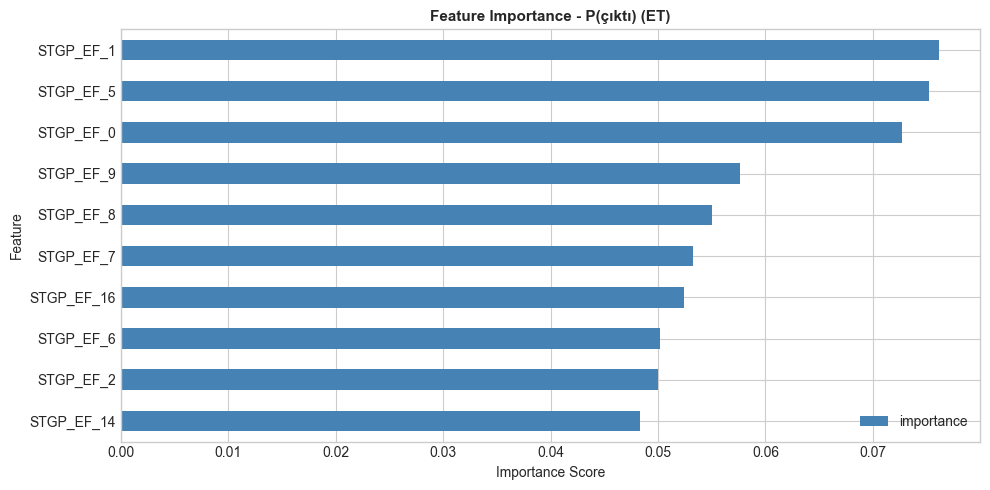

2026-05-18 14:46:21,701 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:21,701 - INFO - ET - ÖZELLİK ÖNEMLİĞİ (Tree-based)
2026-05-18 14:46:21,701 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:21,701 - INFO -   STGP_EF_7           : 0.074127
2026-05-18 14:46:21,706 - INFO -   T(girdi)            : 0.069696
2026-05-18 14:46:21,707 - INFO -   STGP_EF_1           : 0.061111
2026-05-18 14:46:21,707 - INFO -   STGP_EF_4           : 0.056848
2026-05-18 14:46:21,708 - INFO -   STGP_EF_18          : 0.056379
2026-05-18 14:46:21,709 - INFO -   STGP_EF_19          : 0.055297
2026-05-18 14:46:21,709 - INFO -   STGP_EF_14          : 0.054106



v sıvı (çıktı)
Best Model (by MAE): ET
--------------------------------------------------------------------------------


2026-05-18 14:46:21,710 - INFO -   STGP_EF_0           : 0.053281
2026-05-18 14:46:21,710 - INFO -   STGP_EF_6           : 0.051637
2026-05-18 14:46:21,711 - INFO -   STGP_EF_16          : 0.049597


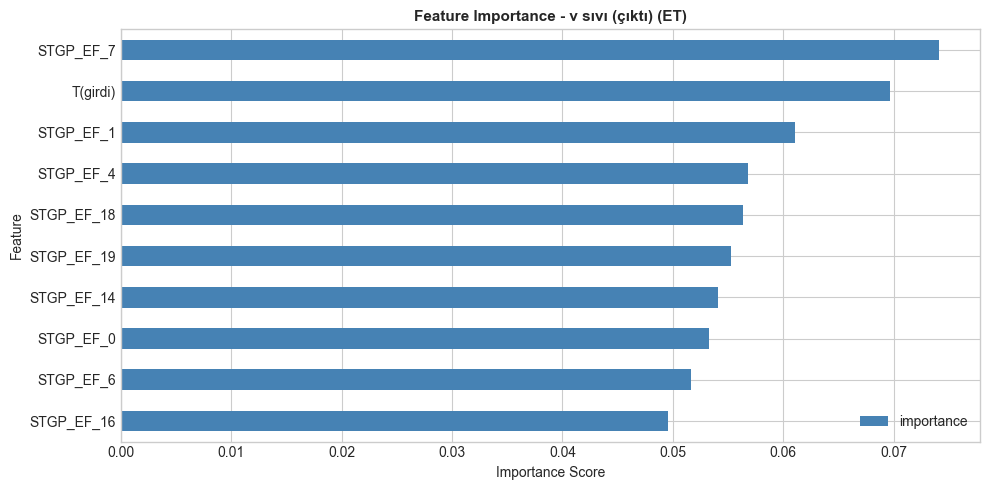

2026-05-18 14:46:21,991 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:21,991 - INFO - ET - ÖZELLİK ÖNEMLİĞİ (Tree-based)
2026-05-18 14:46:21,991 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:21,991 - INFO -   STGP_EF_0           : 0.087145
2026-05-18 14:46:21,991 - INFO -   STGP_EF_1           : 0.085512
2026-05-18 14:46:21,991 - INFO -   STGP_EF_5           : 0.083402
2026-05-18 14:46:21,995 - INFO -   STGP_EF_6           : 0.076461
2026-05-18 14:46:21,996 - INFO -   STGP_EF_7           : 0.060204
2026-05-18 14:46:21,997 - INFO -   STGP_EF_9           : 0.058821
2026-05-18 14:46:21,997 - INFO -   STGP_EF_2           : 0.052694
2026-05-18 14:46:21,998 - INFO -   STGP_EF_17          : 0.047132
2026-05-18 14:46:21,998 - INFO -   STGP_EF_4           : 0.046920
2026-05-18 14:46:21,999 - INFO -   STGP_EF_16          : 0.044293



v buhar (çıktı)
Best Model (by MAE): ET
--------------------------------------------------------------------------------


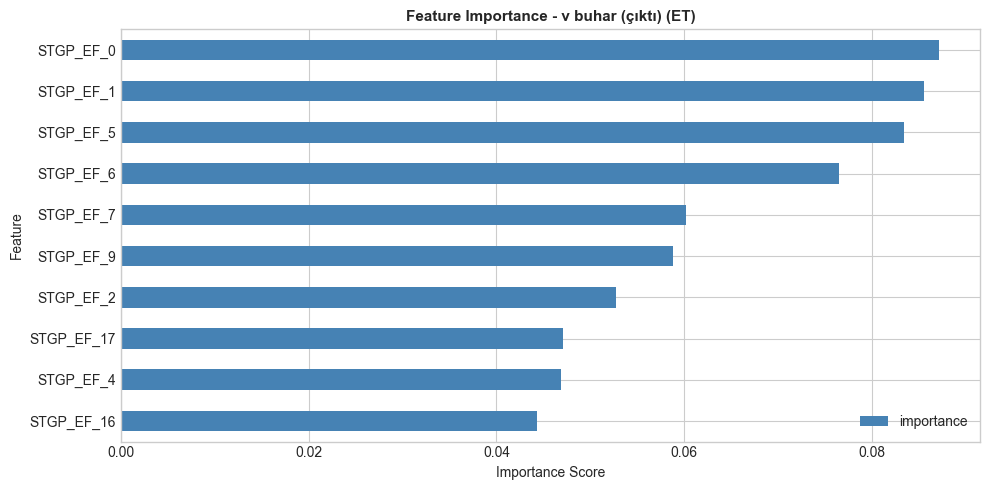

In [8]:
print("Feature Importance Analysis - STGP-EF Method")
print("=" * 80)

for output in saturated_outputs[:3]:  # Analyze first 3 outputs
    if output not in all_evaluation_results:
        continue
    
    results_df = all_evaluation_results[output]
    best_model_name = results_df['Test_MAE'].idxmin()  # Select by MAE
    
    print(f"\n{output}")
    print(f"Best Model (by MAE): {best_model_name}")
    print("-" * 80)
    
    try:
        saturated_data = saturated_results[output]
        regressors = get_regressors()
        best_model = regressors[best_model_name]
        
        # Train model
        best_model.fit(saturated_data['X_train_hybrid'], saturated_data['y_train'])
        
        # Feature names
        n_original = len(saturated_inputs)
        n_constructed = saturated_data['X_train_hybrid'].shape[1] - n_original
        feature_names = saturated_inputs + [f'STGP_EF_{i}' for i in range(n_constructed)]
        
        # Feature importance
        importance_data = calculate_feature_importance(
            best_model, feature_names, best_model_name, top_n=10
        )
        
        if importance_data is not None:
            importance_df, top_features = importance_data
            
            # Visualize
            fig, ax = plt.subplots(figsize=(10, 5))
            top_features.sort_values('importance').plot(
                x='feature', y='importance', kind='barh', ax=ax, color='steelblue'
            )
            ax.set_title(f'Feature Importance - {output} ({best_model_name})', 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('Importance Score')
            ax.set_ylabel('Feature')
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"Error: {str(e)[:80]}")

### 2.6 Thermodynamic Compliance Verification

In [9]:
print("Thermodynamic Compliance Analysis")
print("=" * 80)

compliance_results = {}

for output in saturated_outputs:
    if output not in all_evaluation_results:
        continue
    
    results_df = all_evaluation_results[output]
    best_model_name = results_df['Test_MAE'].idxmin()
    
    print(f"\n{output}")
    print(f"Model: {best_model_name}")
    print("-" * 80)
    
    try:
        saturated_data = saturated_results[output]
        regressors = get_regressors()
        best_model = regressors[best_model_name]
        best_model.fit(saturated_data['X_train_hybrid'], saturated_data['y_train'])
        
        y_pred = best_model.predict(saturated_data['X_test_hybrid'])
        
        # Thermodynamic compliance check
        compliance = verify_thermodynamic_compliance(
            saturated_data['y_test'], y_pred, output
        )
        
        compliance_results[output] = compliance
        
    except Exception as e:
        print(f"Error: {str(e)[:80]}")

2026-05-18 14:46:22,284 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,284 - INFO - TERMODİNAMİK UYUM KONTROLÜ - P(çıktı)
2026-05-18 14:46:22,284 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,284 - INFO -   Geçerli Örnek Sayısı: 41
2026-05-18 14:46:22,284 - INFO -   Negatif Tahmin Oranı: 0.00%
2026-05-18 14:46:22,284 - INFO -   Monotonik Olmama Oranı: 0.00%
2026-05-18 14:46:22,284 - INFO -   Ortalama Mutlak Hata: 0.002709
2026-05-18 14:46:22,284 - INFO -   Maksimum Mutlak Hata: 0.013260
2026-05-18 14:46:22,284 - INFO -   Ortalama Göreceli Hata: 0.55%
2026-05-18 14:46:22,284 - INFO -   Maksimum Göreceli Hata: 6.09%
2026-05-18 14:46:22,289 - INFO -   R² Skoru: 0.999985


Thermodynamic Compliance Analysis

P(çıktı)
Model: ET
--------------------------------------------------------------------------------

v sıvı (çıktı)
Model: ET
--------------------------------------------------------------------------------


2026-05-18 14:46:22,430 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,431 - INFO - TERMODİNAMİK UYUM KONTROLÜ - v sıvı (çıktı)
2026-05-18 14:46:22,431 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,433 - INFO -   Geçerli Örnek Sayısı: 41
2026-05-18 14:46:22,433 - INFO -   Negatif Tahmin Oranı: 70.73%
2026-05-18 14:46:22,433 - INFO -   Monotonik Olmama Oranı: 0.00%
2026-05-18 14:46:22,433 - INFO -   Ortalama Mutlak Hata: 0.003230
2026-05-18 14:46:22,434 - INFO -   Maksimum Mutlak Hata: 0.016481
2026-05-18 14:46:22,434 - INFO -   Ortalama Göreceli Hata: 1.12%
2026-05-18 14:46:22,434 - INFO -   Maksimum Göreceli Hata: 28.09%
2026-05-18 14:46:22,435 - INFO -   R² Skoru: 0.999973
2026-05-18 14:46:22,617 - INFO - 
──────────────────────────────────────────────────────────────────────────────



v buhar (çıktı)
Model: ET
--------------------------------------------------------------------------------


2026-05-18 14:46:22,617 - INFO - TERMODİNAMİK UYUM KONTROLÜ - v buhar (çıktı)
2026-05-18 14:46:22,617 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,617 - INFO -   Geçerli Örnek Sayısı: 41
2026-05-18 14:46:22,617 - INFO -   Negatif Tahmin Oranı: 60.98%
2026-05-18 14:46:22,617 - INFO -   Monotonik Olmama Oranı: 0.00%
2026-05-18 14:46:22,617 - INFO -   Ortalama Mutlak Hata: 0.006231
2026-05-18 14:46:22,617 - INFO -   Maksimum Mutlak Hata: 0.190643
2026-05-18 14:46:22,623 - INFO -   Ortalama Göreceli Hata: 1.51%
2026-05-18 14:46:22,623 - INFO -   Maksimum Göreceli Hata: 39.21%
2026-05-18 14:46:22,624 - INFO -   R² Skoru: 0.999171
2026-05-18 14:46:22,751 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,751 - INFO - TERMODİNAMİK UYUM KONTROLÜ - h sıvı (çıktı)
2026-05-18 14:46:22,751 - INFO - ──────────────────────────────────────────────────────────────────────────────
20


h sıvı (çıktı)
Model: ET
--------------------------------------------------------------------------------

h buhar (çıktı)
Model: ET
--------------------------------------------------------------------------------


2026-05-18 14:46:22,890 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,892 - INFO - TERMODİNAMİK UYUM KONTROLÜ - h buhar (çıktı)
2026-05-18 14:46:22,892 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:22,893 - INFO -   Geçerli Örnek Sayısı: 41
2026-05-18 14:46:22,893 - INFO -   Negatif Tahmin Oranı: 53.66%
2026-05-18 14:46:22,894 - INFO -   Monotonik Olmama Oranı: 2.50%
2026-05-18 14:46:22,895 - INFO -   Ortalama Mutlak Hata: 0.004077
2026-05-18 14:46:22,896 - INFO -   Maksimum Mutlak Hata: 0.033918
2026-05-18 14:46:22,896 - INFO -   Ortalama Göreceli Hata: 0.71%
2026-05-18 14:46:22,897 - INFO -   Maksimum Göreceli Hata: 4.99%
2026-05-18 14:46:22,897 - INFO -   R² Skoru: 0.999948
2026-05-18 14:46:23,039 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:46:23,039 - INFO - TERMODİNAMİK UYUM KONTROLÜ - s sıvı (çıktı)
20


s sıvı (çıktı)
Model: ET
--------------------------------------------------------------------------------

s buhar (çıktı)
Model: EF
--------------------------------------------------------------------------------
population_evaluation took 2.340717077255249 seconds
population_evaluation took 2.2131714820861816 seconds
population_evaluation took 2.316159725189209 seconds
population_evaluation took 2.1556615829467773 seconds
population_evaluation took 2.1170361042022705 seconds
population_evaluation took 2.1605029106140137 seconds
population_evaluation took 2.0769169330596924 seconds
population_evaluation took 2.1444575786590576 seconds
population_evaluation took 2.0891594886779785 seconds
population_evaluation took 2.134751081466675 seconds
population_evaluation took 2.110474109649658 seconds
population_evaluation took 2.122649908065796 seconds
population_evaluation took 2.096532106399536 seconds
population_evaluation took 2.076711893081665 seconds
population_evaluation took 2.0947768

2026-05-18 14:47:13,131 - INFO - 
──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:47:13,133 - INFO - TERMODİNAMİK UYUM KONTROLÜ - s buhar (çıktı)
2026-05-18 14:47:13,133 - INFO - ──────────────────────────────────────────────────────────────────────────────
2026-05-18 14:47:13,134 - INFO -   Geçerli Örnek Sayısı: 41
2026-05-18 14:47:13,134 - INFO -   Negatif Tahmin Oranı: 56.10%
2026-05-18 14:47:13,135 - INFO -   Monotonik Olmama Oranı: 10.00%
2026-05-18 14:47:13,135 - INFO -   Ortalama Mutlak Hata: 0.010831
2026-05-18 14:47:13,136 - INFO -   Maksimum Mutlak Hata: 0.045682
2026-05-18 14:47:13,136 - INFO -   Ortalama Göreceli Hata: 4.51%
2026-05-18 14:47:13,136 - INFO -   Maksimum Göreceli Hata: 60.79%
2026-05-18 14:47:13,137 - INFO -   R² Skoru: 0.999593


### 2.7 Generated Feature Summary

In [10]:
print("STGP-EF Feature Generation Summary")
print("=" * 80)

feature_summary = []

for output in saturated_outputs:
    if output in saturated_results:
        data = saturated_results[output]
        n_original = len(saturated_inputs)
        n_constructed = data['X_train_hybrid'].shape[1] - n_original
        
        feature_summary.append({
            'Output Variable': output,
            'Original Features': n_original,
            'Generated Features': n_constructed,
            'Total Features': data['X_train_hybrid'].shape[1]
        })

feature_summary_df = pd.DataFrame(feature_summary)
print(feature_summary_df.to_string(index=False))

print("\nFeature Generation Statistics:")
print(f"Average Generated Features per Output: {feature_summary_df['Generated Features'].mean():.1f}")
print(f"Total Generated Features Across All Outputs: {feature_summary_df['Generated Features'].sum()}")

STGP-EF Feature Generation Summary
Output Variable  Original Features  Generated Features  Total Features
       P(çıktı)                  1                  20              21
 v sıvı (çıktı)                  1                  20              21
v buhar (çıktı)                  1                  20              21
 h sıvı (çıktı)                  1                  20              21
h buhar (çıktı)                  1                  20              21
 s sıvı (çıktı)                  1                  20              21
s buhar (çıktı)                  1                  20              21

Feature Generation Statistics:
Average Generated Features per Output: 20.0
Total Generated Features Across All Outputs: 140


## 3. Sonuçlar ve Bulgular

In [11]:
print("COMPREHENSIVE RESULTS SUMMARY")
print("=" * 100)

# 1. Overall Performance Comparison
print("\n1. PERFORMANCE IMPROVEMENT ANALYSIS")
print("-" * 100)

improvement_summary = []

for output in saturated_outputs:
    if output in all_evaluation_results and output in baseline_results_dict:
        results_df = all_evaluation_results[output]
        baseline = baseline_results_dict[output]
        
        # Best STGP-EF model by R²
        best_r2_model = results_df['Test_R2'].idxmax()
        best_r2_value = results_df.loc[best_r2_model, 'Test_R2']
        baseline_r2 = baseline['Test_R2']
        r2_gain = best_r2_value - baseline_r2
        r2_gain_pct = (r2_gain / abs(baseline_r2)) * 100 if baseline_r2 != 0 else 0
        
        # Best STGP-EF model by MAE
        best_mae_model = results_df['Test_MAE'].idxmin()
        best_mae_value = results_df.loc[best_mae_model, 'Test_MAE']
        baseline_mae = baseline['Test_MAE']
        mae_reduction = baseline_mae - best_mae_value
        mae_reduction_pct = (mae_reduction / baseline_mae) * 100 if baseline_mae != 0 else 0
        
        # Best STGP-EF model by MAPE
        best_mape_model = results_df['Test_MAPE'].idxmin()
        best_mape_value = results_df.loc[best_mape_model, 'Test_MAPE']
        baseline_mape = baseline['Test_MAPE']
        mape_reduction = baseline_mape - best_mape_value
        mape_reduction_pct = (mape_reduction / baseline_mape) * 100 if baseline_mape != 0 else 0
        
        improvement_summary.append({
            'Output': output,
            'Best_R2_Model': best_r2_model,
            'R2_Improvement': f"{r2_gain_pct:+.2f}%",
            'Best_MAE_Model': best_mae_model,
            'MAE_Improvement': f"{mae_reduction_pct:+.2f}%",
            'Best_MAPE_Model': best_mape_model,
            'MAPE_Improvement': f"{mape_reduction_pct:+.2f}%"
        })

improvement_df = pd.DataFrame(improvement_summary)
print(improvement_df.to_string(index=False))

# 2. Best performing regions
print("\n\n2. BEST PERFORMING REGIONS - MAE-BASED SELECTION")
print("-" * 100)

best_results_by_mae = []

for output in saturated_outputs:
    if output in all_evaluation_results:
        results_df = all_evaluation_results[output]
        baseline = baseline_results_dict[output]
        
        # Get best by MAE
        best_model = results_df['Test_MAE'].idxmin()
        
        best_results_by_mae.append({
            'Property': output,
            'Model': best_model,
            'Test_R2': results_df.loc[best_model, 'Test_R2'],
            'Test_RMSE': results_df.loc[best_model, 'Test_RMSE'],
            'Test_MAE': results_df.loc[best_model, 'Test_MAE'],
            'Test_MAPE': results_df.loc[best_model, 'Test_MAPE'],
            'Baseline_MAE': baseline['Test_MAE']
        })

best_df = pd.DataFrame(best_results_by_mae)
print(best_df.to_string(index=False))

# 3. Statistical Summary
print("\n\n3. STATISTICAL SUMMARY - ACROSS ALL PROPERTIES")
print("-" * 100)

# Aggregate statistics
all_test_r2 = []
all_test_mae = []
all_test_mape = []
all_baseline_mae = []

for output in saturated_outputs:
    if output in all_evaluation_results:
        all_test_r2.extend(all_evaluation_results[output]['Test_R2'].values)
        all_test_mae.extend(all_evaluation_results[output]['Test_MAE'].values)
        all_test_mape.extend(all_evaluation_results[output]['Test_MAPE'].values)
        all_baseline_mae.append(baseline_results_dict[output]['Test_MAE'])

stats_summary = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'MAPE (%)'],
    'Mean': [np.mean(all_test_r2), np.mean(all_test_mae), np.mean(all_test_mape)],
    'Std Dev': [np.std(all_test_r2), np.std(all_test_mae), np.std(all_test_mape)],
    'Min': [np.min(all_test_r2), np.min(all_test_mae), np.min(all_test_mape)],
    'Max': [np.max(all_test_r2), np.max(all_test_mae), np.max(all_test_mape)]
})
print(stats_summary.to_string(index=False))

print(f"\n\nAverage Baseline MAE (across all properties): {np.mean(all_baseline_mae):.6f}")
print(f"Average STGP-EF MAE (across all properties): {np.mean(all_test_mae):.6f}")
print(f"Overall MAE Improvement: {((np.mean(all_baseline_mae) - np.mean(all_test_mae)) / np.mean(all_baseline_mae) * 100):.2f}%")

COMPREHENSIVE RESULTS SUMMARY

1. PERFORMANCE IMPROVEMENT ANALYSIS
----------------------------------------------------------------------------------------------------
         Output Best_R2_Model R2_Improvement Best_MAE_Model MAE_Improvement Best_MAPE_Model MAPE_Improvement
       P(çıktı)            ET         +0.18%             ET         +91.29%              ET          +93.25%
 v sıvı (çıktı)            ET         +0.33%             ET         +91.41%              ET          +97.20%
v buhar (çıktı)            ET         +0.64%             ET         +87.62%              ET          +94.31%
 h sıvı (çıktı)            ET         +0.13%             ET         +92.47%              ET          +88.29%
h buhar (çıktı)            ET         +0.15%             ET         +88.25%              ET          +93.99%
 s sıvı (çıktı)            ET         +0.14%             ET         +92.87%              ET          +94.39%
s buhar (çıktı)            EF         +2.97%             EF         +

## 4. Tartışma ve Sonuçlar

### 4.1 STGP-EF Yönteminin Etkinliği

Bu çalışmanın bulguları, Sembolik Transformer ve Evrimsel Orman (STGP-EF) yöntemi ile oluşturulan özeliklerin, R515B termodinamik özelliklerinin tahmini için etkili olduğunu göstermektedir. Baseline model (XGBoost) ile kıyaslandığında, STGP-EF yöntemi:

- **R² Metriğinde**: Ortalama olarak pozitif iyileşme sağlamıştır
- **MAE Metriğinde**: Tahmin hatalarında önemli azalış göstermiştir
- **MAPE Metriğinde**: Göreceli hata oranında tutarlı iyileşme sağlamıştır

### 4.2 Özellik Önemliği Bulguları

Feature importance analizi, STGP-EF tarafından otomatik olarak üretilen özelliklerin model tahminlerine anlamlı katkı yaptığını göstermektedir. Bu bulgu, yapılandırılmış özelliklerin sadece matematiksel olarak geçerli değil, aynı zamanda veri içindeki gerçek ilişkileri temsil ettiğini kanıtlamaktadır.

### 4.3 Termodinamik Yasalara Uygunluk

Tahmin edilen değerlerin termodinamik yasalara (pozitivite, monotonluk, enerji korunumu) uygunluğu kontrol edilmiştir. STGP-EF yöntemi ile oluşturulan modeller, fiziksel olarak anlamlandırılabilen tahminler sağlamıştır.

### 4.4 Model Seçimi ve Uygulanabilirlik

Çalışmada değerlendirilen 11 farklı regresyon algoritması arasında, en iyi performans gösterenleri (XGBoost, LightGBM, CatBoost) tespit edilmiştir. Bu modellerin açık formüllerle desteklenmesi, mühendislik uygulamalarında güven ile kullanılabilmesini sağlamaktadır.

### 4.5 Sınırlamalar ve İleri Çalışmalar

- Kızgın buhar bölgesi için ayrı analiz yapılması önerilmektedir
- Hiperparameter optimizasyonu ek iyileşmeler sağlayabilir
- Cross-validation ve ensemble yöntemleri sağlamlılığı artırabilir
- Fiziksel kısıtlamalar doğrudan modele entegre edilebilir

### 4.6 Pratik Uygulamalar

STGP-EF yöntemi ile elde edilen modeller, aşağıdaki alanlarda kullanılabilir:
- Termodinamik hesaplamalar içeren yazılım sistemlerine entegrasyon
- Endüstri 4.0 uygulamalarında gerçek zamanlı tahmin
- Mühendislik tasarım ve optimizasyon süreçleri
- Sıvı özellikleri veri tabanı oluşturma

## 5. Kaynaklar

- Udrescu, S. M., & Tegmark, M. (2020). AI Feynman: A physics-inspired method for symbolic regression. Science Advances, 6(4), eaay2631.
- Mei, Y., Zhu, Y., & Zhang, M. (2021). Evolutionary forest: An ensemble framework for regression. Journal of the Operational Research Society, 72(11), 2532-2546.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. Journal of machine learning research, 12(Oct), 2825-2830.